# CatBoost Learning Notebook


This notebook shows how to use **CatBoost** for classification and regression,
including handling categorical columns.

Advantages:

handles categorical variables automatically

less preprocessing needed

Used for:

tabular ML

business data

recommendation systems

## Jupyter setup

```bash
pip install catboost scikit-learn pandas numpy matplotlib jupyter
jupyter notebook
```

## Imports

In [1]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
print("CatBoost imported successfully.")

CatBoost imported successfully.


## Categorical classification example

In [2]:
df = pd.DataFrame({
    "city": ["Toronto", "Montreal", "Toronto", "Vancouver", "Montreal", "Toronto", "Vancouver", "Toronto"],
    "plan": ["A", "A", "B", "B", "C", "C", "A", "B"],
    "visits": [10, 7, 15, 8, 4, 11, 5, 14],
    "spent": [120, 80, 200, 95, 40, 150, 60, 190],
    "target": [1, 0, 1, 0, 0, 1, 0, 1]
})
X = df.drop(columns="target")
y = df["target"]
cat_features = [0, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=4, verbose=0)
model.fit(X_train, y_train, cat_features=cat_features)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## Pool objects

In [3]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)
print(train_pool)

## Feature importance

city      49.295725
visits    43.745347
spent      6.096968
plan       0.861960
dtype: float64


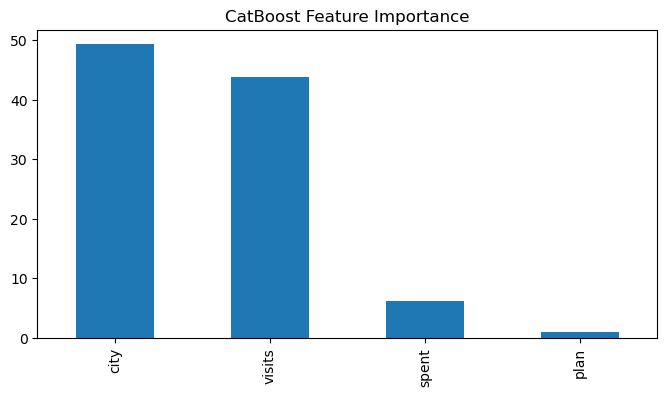

In [4]:
imp = pd.Series(model.get_feature_importance(), index=X.columns).sort_values(ascending=False)
print(imp)
imp.plot(kind="bar", figsize=(8,4), title="CatBoost Feature Importance")
plt.show()

## Useful classes and methods

In [5]:
reference = {
    "Models": ["CatBoostClassifier", "CatBoostRegressor", "Pool"],
    "Methods": ["fit", "predict", "predict_proba", "get_feature_importance", "save_model", "load_model"],
    "Key params": ["iterations", "learning_rate", "depth", "loss_function", "verbose"]
}
for k, v in reference.items():
    print("\n" + k + ":")
    print(", ".join(v))


Models:
CatBoostClassifier, CatBoostRegressor, Pool

Methods:
fit, predict, predict_proba, get_feature_importance, save_model, load_model

Key params:
iterations, learning_rate, depth, loss_function, verbose
